# Pairwise model comparison using BTM metrics 

The aim of this notebook is to compare two models using BTM metrics.

## Setting libraries

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import pipeline.src.python.config as cfg
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth', None)
import torch
from sentence_transformers import SentenceTransformer
import networkx as nx

/home/banfi/.uve/cuda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Select the models to compare

In [3]:
MAGAZINE_1 = 'science_news'
DATASET_TEXT_FEATURE = (
    "text"  # In the dataset file, the column name that contains the text data
)
cfg_dict_1 = cfg.MAGAZINE_CONFIG[MAGAZINE_1]

In [4]:
MAGAZINE_2 = 'scopus'
cfg_dict_2 = cfg.MAGAZINE_CONFIG[MAGAZINE_2]

## Loading models

In [5]:
embedding_model = SentenceTransformer(
    cfg.EMBEDDING_MODEL,            
    device="cuda",                  
    model_kwargs={"dtype": torch.bfloat16},  
)

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 18.00it/s]


In [6]:
from bertopic import BERTopic

model_path = cfg_dict_1['REFERENCE_MODEL']
model_1 = BERTopic.load(model_path, 
                      embedding_model=embedding_model
                      )

In [7]:
model_path_2 = cfg_dict_2['REFERENCE_MODEL']
model_2 = BERTopic.load(model_path_2,
                        embedding_model=embedding_model
                        )

## Loading data

In [8]:
data = np.load(cfg_dict_1['OUTPUT_PATH'],allow_pickle=True) 

ids = data['id']
texts = data['text'] 
embeddings = data['embedding']

In [9]:
data_2 = np.load(cfg_dict_2['OUTPUT_PATH'],allow_pickle=True) 

ids_2 = data_2['id']
texts_2 = data_2['text'] 
embeddings_2 = data_2['embedding']

## Metrics Evaluation - Model 1 -> Model 2

### Metrics computation

In [10]:
model_2_topic_labels = { idx:topic for idx, topic in enumerate(model_2.custom_labels_,start=-1) }

In [11]:
from pipeline.src.python.btm import BTM

models_metrics = BTM(model_1=model_1,
                     model_2=model_2,
                     ids_1=ids,
                     texts_1=texts,
                     embeddings_1=embeddings,
                     texts_2=texts_2,
                     embeddings_2=embeddings_2,
                     model_1_name=MAGAZINE_1.title(),
                     model_2_name=MAGAZINE_2.title(),
                     percentile_threshold=0.01
                     )

2026-05-29 10:25:36,127 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


2026-05-29 10:25:59,971 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.24699661791324615
70/868 are classified as outlier due to their threshold values


In [12]:
models_metrics.evaluate_metrics()

### Metrics visualization

In [13]:
models_metrics.print_corpus_metrics()

Evaluation: Science_News -> Scopus
Corpus Closeness: 0.7000346586474776
Evaluation: Science_News -> Scopus
Corpus Uniqueness: 0.29996534135252234
Evaluation: Science_News -> Scopus
Corpus Alignment: 0.3763497435292503


In [14]:
models_metrics.print_weighted_corpus_metrics()

Evaluation: The_Guardian -> Scopus
Corpus Closeness: 0.3632081169223336
Evaluation: The_Guardian -> Scopus
Corpus Uniqueness: 0.6367918830776664
Evaluation: The_Guardian -> Scopus
Corpus Alignment: 0.24495712042517212


### Display the top 10 topics with the highest topic closeness 

In [15]:
closeness_from_1_to_2 = models_metrics.get_topic_closeness().sort_values(by='Topic Closeness',ascending=False)

In [16]:
closeness_from_1_to_2.to_csv(f'./BTM_metrics/{MAGAZINE_1.title()}_vs_{MAGAZINE_2.title()}_closeness.csv',sep='ç',encoding='utf-8')

In [17]:
from great_tables import GT, style, loc

top_10_closeness_from_1_to_2 = closeness_from_1_to_2.head(10)
GT(top_10_closeness_from_1_to_2)\
    .tab_style(
      style=[
          style.fill(color="#2c3e50"),
          style.text(color="white", weight="bold", align="center",v_align="middle")
      ],
      locations=loc.column_labels()
  )\
  .tab_style(
      style=[
          style.text(size="18px", weight="bold"),
          style.fill(color="#ecf0f1")
      ],
      locations=loc.title()
  )\
  .tab_style(
      style=style.text(weight="bold", align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_1.title()} Topic Label", f"{MAGAZINE_2.title()} Topic Label", "Topic Closeness"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_1.title()} Topic Id", f"{MAGAZINE_2.title()} Topic Id","Total Couple matches","Topic Corpus Occurrences"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.column_labels()
  ).fmt_number(columns=["Topic Closeness"], decimals=4)\
    .tab_style(
      style=style.fill(color="#4a9ed6"),
      locations=loc.body(rows=[i for i in range(len(top_10_closeness_from_1_to_2)) if i % 2 == 0])
  )\
  .tab_style(
      style=style.fill(color="white"),
      locations=loc.body(rows=[i for i in range(len(top_10_closeness_from_1_to_2)) if i % 2 != 0])
  )

The_Guardian Topic Id,Scopus Topic Id,The_Guardian Topic Label,Scopus Topic Label,Total Couple matches,Topic Corpus Occurrences,Topic Closeness
73,12,Monkeypox outbreak vaccination response,Monkeypox (Mpox) Orthopoxvirus Infection,113,116,0.9741
98,123,NHS COVID-19 Contact Tracing Apps,Mobile COVID-19 Contact Tracing,66,72,0.9167
104,111,Antibiotic Resistance and Stewardship,Veterinary Antimicrobial Use and Resistance,57,64,0.8906
56,0,Multidrug-Resistant Tuberculosis Outbreaks,Multidrug-Resistant Tuberculosis Management,128,146,0.8767
115,21,COVID-19 Vaccine Safety and Risks,Vaccine Safety Surveillance Systems,46,58,0.7931
40,195,Global Vaccine Access and Equity,Immunization Coverage and Programs,153,194,0.7887
27,115,Post-COVID Long-Term Symptoms,Post-COVID-19 Long-Term Sequelae,187,243,0.7695
45,142,Nursing Home Pandemic Care Failures,COVID-19 in Nursing Homes,140,182,0.7692
35,17,SARS-CoV-2 Variant Strains,SARS-CoV-2 Genomic Variant Evolution,150,199,0.7538
72,54,Adolescent Sexual Health and STIs,Chlamydia Gonorrhea Syphilis Infections,84,118,0.7119


Number of topics with topic closeness >= 0.5

In [ ]:
len( closeness_from_1_to_2[ closeness_from_1_to_2['Topic Closeness'] >= 0.5 ] )

### Word Cloud - Topic comparison

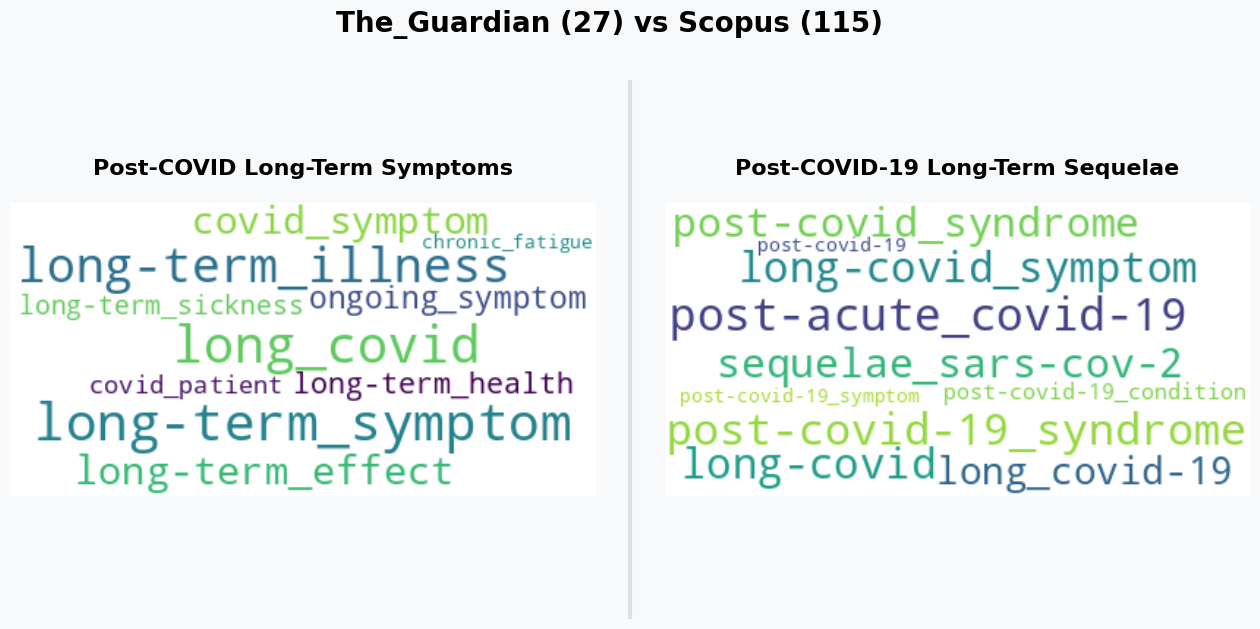

In [59]:
models_metrics.compare_wordcloud_topics(27,115)

### Display the top 10 topics with the highest topic uniqueness 

In [22]:
uniqueness_from_1_to_2 = models_metrics.get_topic_uniqueness().sort_values(by='Topic Uniqueness',ascending=False)

In [ ]:
uniqueness_from_1_to_2.to_csv(f'./BTM_metrics/{MAGAZINE_1.title()}_vs_{MAGAZINE_2.title()}_uniqueness.csv',sep='ç',encoding='utf-8')

In [23]:
from great_tables import GT, style, loc

top_10_uniqueness_from_1_to_2 = uniqueness_from_1_to_2[ uniqueness_from_1_to_2['Topic Uniqueness'] >= 0.5 ].head(10)
GT(top_10_uniqueness_from_1_to_2)\
    .tab_style(
      style=[
          style.fill(color="#3f2c50"),
          style.text(color="white", weight="bold", align="center",v_align="middle")
      ],
      locations=loc.column_labels()
  )\
  .tab_style(
      style=[
          style.text(size="18px", weight="bold"),
          style.fill(color="#ecf0f1")
      ],
      locations=loc.title()
  )\
  .tab_style(
      style=style.text(weight="bold", align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_1.title()} Topic Label", "Topic Uniqueness"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_1.title()} Topic Id"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.column_labels()
  ).fmt_number(columns=["Topic Uniqueness"], decimals=4)\
    .tab_style(
      style=[style.fill(color="#584ad6"),style.text(color='white')],
      locations=loc.body(rows=[i for i in range(len(top_10_uniqueness_from_1_to_2)) if i % 2 == 0])
  )\
  .tab_style(
      style=style.fill(color="white"),
      locations=loc.body(rows=[i for i in range(len(top_10_uniqueness_from_1_to_2)) if i % 2 != 0])
  )

The_Guardian Topic Label,The_Guardian Topic Id,Topic Uniqueness
UK lockdown breach scandal,88,0.9765
Nostalgic British Pop Debut Albums,110,0.9516
Libya HIV Criminalization Controversy,123,0.9444
Post-Pandemic Aviation and Retail Recovery,4,0.9344
Anti-Lockdown Protest Movement,125,0.9245
Global Government Surveillance Programs,62,0.9154
Pandemic-driven Home Cooking Demand,105,0.9062
Emotionally Resonant Social Television Storytelling,54,0.8993
Lockdown-era Banksy Sculpture Exhibition,71,0.8908
Protests against COVID-19 measures,95,0.8861


Total number of topics with uniqueness >= 0.5

In [ ]:
len( top_10_uniqueness_from_1_to_2[ top_10_uniqueness_from_1_to_2['Topic Uniqueness']>= 0.5])

13

### Alignment metrics

In [ ]:
alignment_from_1_to_2 = models_metrics.topic_alignment.sort_values(by='Alignment',ascending=False)

In [ ]:
alignment_from_1_to_2.to_csv(f'./BTM_metrics/{MAGAZINE_1.title()}_vs_{MAGAZINE_2.title()}_alignment.csv',sep='ç',encoding='utf-8')

## Metrics Evaluation Model 2 -> Model 1

### Metrics computation

In [13]:
inverse_models_metrics = BTM(model_1=model_2,
                             model_2=model_1,
                             ids_1=ids_2,
                             texts_1=texts_2,
                             embeddings_1=embeddings_2,
                             texts_2=texts,
                             embeddings_2=embeddings,
                             model_1_name=MAGAZINE_2.title(),
                             model_2_name=MAGAZINE_1.title(),
                             percentile_threshold=0.01
                             )

2026-05-29 10:26:00,387 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-05-29 10:26:00,433 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.27406691402196887
97254/155749 are classified as outlier due to their threshold values


In [14]:
inverse_models_metrics.evaluate_metrics()

### Metrics visualization

In [20]:
inverse_models_metrics.print_corpus_metrics()

Evaluation: Scopus -> The_Guardian
Corpus Closeness: 0.19253399133457189
Evaluation: Scopus -> The_Guardian
Corpus Uniqueness: 0.8074660086654282
Evaluation: Scopus -> The_Guardian
Corpus Alignment: 0.13159493064123245


In [21]:
inverse_models_metrics.print_weighted_corpus_metrics()

Evaluation: Scopus -> The_Guardian
Corpus Closeness: 0.22682649647830805
Evaluation: Scopus -> The_Guardian
Corpus Uniqueness: 0.773173503521692
Evaluation: Scopus -> The_Guardian
Corpus Alignment: 0.1652273850875447


### Display the top 10 topics with the highest topic closeness 

In [31]:
closeness_from_2_to_1 = inverse_models_metrics.get_topic_closeness().sort_values(by='Topic Closeness',ascending=False)

In [ ]:
closeness_from_2_to_1.to_csv(f'./BTM_metrics/{MAGAZINE_2.title()}_vs_{MAGAZINE_1.title()}_closeness.csv',sep='ç',encoding='utf-8')

In [32]:
from great_tables import GT, style, loc

top_10_closeness_from_2_to_1 = closeness_from_2_to_1.head(10)
GT(top_10_closeness_from_2_to_1)\
    .tab_style(
      style=[
          style.fill(color="#2c3e50"),
          style.text(color="white", weight="bold", align="center",v_align="middle")
      ],
      locations=loc.column_labels()
  )\
  .tab_style(
      style=[
          style.text(size="18px", weight="bold"),
          style.fill(color="#ecf0f1")
      ],
      locations=loc.title()
  )\
  .tab_style(
      style=style.text(weight="bold", align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_2.title()} Topic Label", f"{MAGAZINE_1.title()} Topic Label", "Topic Closeness"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_2.title()} Topic Id", f"{MAGAZINE_1.title()} Topic Id","Total Couple matches","Topic Corpus Occurrences"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.column_labels()
  ).fmt_number(columns=["Topic Closeness"], decimals=4)\
    .tab_style(
      style=style.fill(color="#4a9ed6"),
      locations=loc.body(rows=[i for i in range(len(top_10_closeness_from_2_to_1)) if i % 2 == 0])
  )\
  .tab_style(
      style=style.fill(color="white"),
      locations=loc.body(rows=[i for i in range(len(top_10_closeness_from_2_to_1)) if i % 2 != 0])
  )

Science_News Topic Id,The_Guardian Topic Id,Science_News Topic Label,The_Guardian Topic Label,Total Couple matches,Topic Corpus Occurrences,Topic Closeness
10,39,Zika Virus Outbreak and Fetal Impact,Zika and Dengue Outbreaks,31,32,0.9688
16,21,Antibiotic-resistant bacterial pathogens,Antibiotic Resistance and Superbugs,21,23,0.9130
9,27,Post-Acute COVID-19 Syndrome,Post-COVID Long-Term Symptoms,29,32,0.9062
21,35,Vaccine Efficacy against Omicron,SARS-CoV-2 Variant Strains,16,18,0.8889
0,5,Human Transmission of Avian Influenza,H5N1 Avian Influenza in Poultry,45,64,0.7031
33,56,Mycobacterium tuberculosis genetic diversity,Multidrug-Resistant Tuberculosis Outbreaks,7,10,0.7000
22,119,COVID-19 Vaccination and Outcomes,COVID-19 Vaccine Efficacy and Immunity,11,16,0.6875
2,116,Antiviral and Vaccine Therapies,COVID-19 Antiviral Treatments,34,53,0.6415
32,34,Gut Microbiome Influence on Cancer,Human Whole-Genome Sequencing Research,6,10,0.6000
17,48,Wastewater Based Outbreak Surveillance,Environmental Drivers of Zoonotic Spillover,11,19,0.5789


In [ ]:
len( top_10_closeness_from_2_to_1[ top_10_closeness_from_2_to_1['Topic Closeness'] >= 0.5 ] )

32

### Display the top 10 topics with the highest topic uniqueness 

In [33]:
uniqueness_from_2_to_1 = inverse_models_metrics.get_topic_uniqueness().sort_values(by='Topic Uniqueness',ascending=False)

In [34]:
from great_tables import GT, style, loc

top_10_uniqueness_from_2_to_1 = uniqueness_from_2_to_1.head(10)
GT(top_10_uniqueness_from_2_to_1)\
    .tab_style(
      style=[
          style.fill(color="#3f2c50"),
          style.text(color="white", weight="bold", align="center",v_align="middle")
      ],
      locations=loc.column_labels()
  )\
  .tab_style(
      style=[
          style.text(size="18px", weight="bold"),
          style.fill(color="#ecf0f1")
      ],
      locations=loc.title()
  )\
  .tab_style(
      style=style.text(weight="bold", align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_2.title()} Topic Label", "Topic Uniqueness"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_2.title()} Topic Id"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.column_labels()
  ).fmt_number(columns=["Topic Uniqueness"], decimals=4)\
    .tab_style(
      style=[style.fill(color="#584ad6"),style.text(color='white')],
      locations=loc.body(rows=[i for i in range(len(top_10_uniqueness_from_2_to_1)) if i % 2 == 0])
  )\
  .tab_style(
      style=style.fill(color="white"),
      locations=loc.body(rows=[i for i in range(len(top_10_uniqueness_from_2_to_1)) if i % 2 != 0])
  )

Science_News Topic Label,Science_News Topic Id,Topic Uniqueness
Pathogen-based cancer immunotherapies,20,0.5556
Bacterial Biofilms and Phage Interactions,26,0.5000
Synthetic Microbial Genome Engineering,13,0.4348
CRISPR-Cas9 HIV Gene Therapy,34,0.4000
Antibiotic resistance gene evolution,14,0.3913
HIV infection and viral load,12,0.3846
HIV/AIDS transmission and coinfections in Africa,28,0.3333
Equitable Scientific Research and Innovation,8,0.3030
HIV replication and treatment dynamics,29,0.2727
Genetic Control of Aedes Mosquitoes,18,0.2105


In [ ]:
uniqueness_from_2_to_1.to_csv(f'./BTM_metrics/{MAGAZINE_2.title()}_vs_{MAGAZINE_1.title()}_uniqueness.csv',sep='ç',encoding='utf-8')

In [39]:
len( uniqueness_from_2_to_1[ uniqueness_from_2_to_1['Topic Uniqueness'] >= 0.5 ] )

237

### Alignment metrics

In [ ]:
alignment_from_2_to_1 = inverse_models_metrics.topic_alignment.sort_values(by='Alignment',ascending=False)

,Topic_model_1,Topic_label_model_1,Count,Alignment,Weigth
31,32,COVID-19 cases and deaths,209,0.966507,202.0
109,116,COVID-19 Antiviral Treatments,57,0.964912,55.0
34,35,SARS-CoV-2 Variant Strains,199,0.934673,186.0
99,104,Antibiotic Resistance and Stewardship,64,0.906250,58.0
26,27,Post-COVID Long-Term Symptoms,243,0.905350,220.0
...,...,...,...,...,...
70,71,Lockdown-era Banksy Sculpture Exhibition,119,0.008403,1.0
61,62,Global Government Surveillance Programs,130,0.007692,1.0
18,18,Live Performing Arts Festivals,298,0.006711,2.0
43,44,Australian Economy and Unemployment,184,0.005435,1.0


In [ ]:
alignment_from_2_to_1.to_csv(f'./BTM_metrics/{MAGAZINE_2.title()}_vs_{MAGAZINE_1.title()}_alignment.csv',sep='ç',encoding='utf-8')

## Density estimation

In [15]:
color_map = {'The_Guardian' : 'green',
             'Science_News' : 'blue',
             'Scopus' : 'red'}

### Density of topic closeness connections (no aggregation)

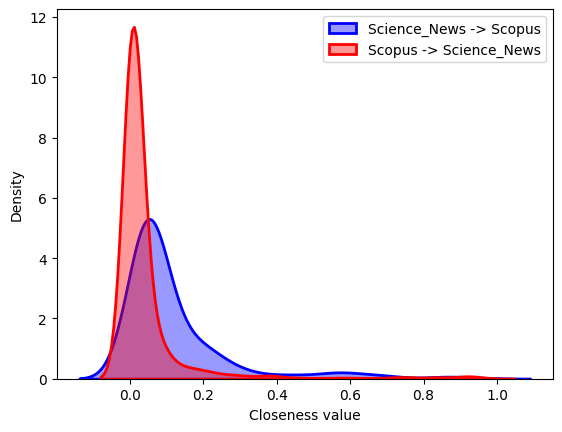

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

model1_to_model2_closeness_values = models_metrics.get_topic_closeness()['Topic Closeness']
model2_to_model1_closeness_values = inverse_models_metrics.get_topic_closeness()['Topic Closeness']

sns.kdeplot(model1_to_model2_closeness_values,
            fill=True,
            alpha=0.4,
            linewidth=2,
            label=f"{models_metrics.model_1_name} -> {models_metrics.model_2_name}",
            color=color_map[models_metrics.model_1_name]
            )

sns.kdeplot(model2_to_model1_closeness_values,
            fill=True,
            alpha=0.4,
            linewidth=2,
            label=f"{inverse_models_metrics.model_1_name} -> {inverse_models_metrics.model_2_name}",
            color=color_map[inverse_models_metrics.model_1_name]
            )

plt.legend()

plt.xlabel("Closeness value")
plt.ylabel("Density")

plt.savefig(f'./figures/compare_model_with_BTM_score_figures/{models_metrics.model_1_name}_{models_metrics.model_2_name}_closeness_distribution_{models_metrics.percentile_threshold}.png',
            dpi=300,
            bbox_inches="tight")
plt.show()

### Density of topic closeness (aggregated)

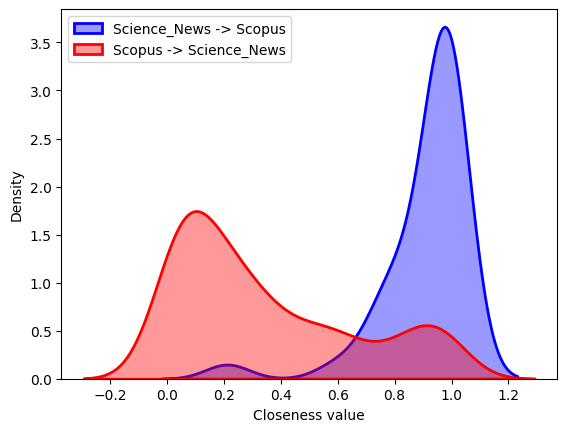

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


aggregated_model1_to_model2_closeness_values = models_metrics.get_topic_closeness()[['Science_News Topic Label','Topic Closeness']].groupby('Science_News Topic Label').sum().reset_index()['Topic Closeness']
full_unique_topics_model_1 = pd.Series(np.zeros( models_metrics.n_topics_model_1 - len(aggregated_model1_to_model2_closeness_values)))
aggregated_model_1_values = pd.concat( [aggregated_model1_to_model2_closeness_values,full_unique_topics_model_1])

aggregated_model2_to_model1_closeness_values = inverse_models_metrics.get_topic_closeness()[['Scopus Topic Label','Topic Closeness']].groupby('Scopus Topic Label').sum().reset_index()['Topic Closeness']
full_unique_topics_model_2 = pd.Series(np.zeros( inverse_models_metrics.n_topics_model_1 - len(aggregated_model2_to_model1_closeness_values)))
aggregated_model_2_values = pd.concat( [aggregated_model2_to_model1_closeness_values,full_unique_topics_model_2])

sns.kdeplot(aggregated_model_1_values,
            fill=True,
            alpha=0.4,
            linewidth=2,
            label=f"{models_metrics.model_1_name} -> {models_metrics.model_2_name}",
            color=color_map[models_metrics.model_1_name]
            )
sns.kdeplot(aggregated_model_2_values,
            fill=True,
            alpha=0.4,
            linewidth=2,
            label=f"{inverse_models_metrics.model_1_name} -> {inverse_models_metrics.model_2_name}",
            color=color_map[inverse_models_metrics.model_1_name]
            )

plt.legend()

plt.xlabel("Closeness value")
plt.ylabel("Density")

plt.savefig(f'./figures/compare_model_with_BTM_score_figures/{models_metrics.model_1_name}_{models_metrics.model_2_name}_aggregate_closeness_distribution_{models_metrics.percentile_threshold}.png',
            dpi=300,
            bbox_inches="tight")

plt.show()

### Density of topic uniqueness 

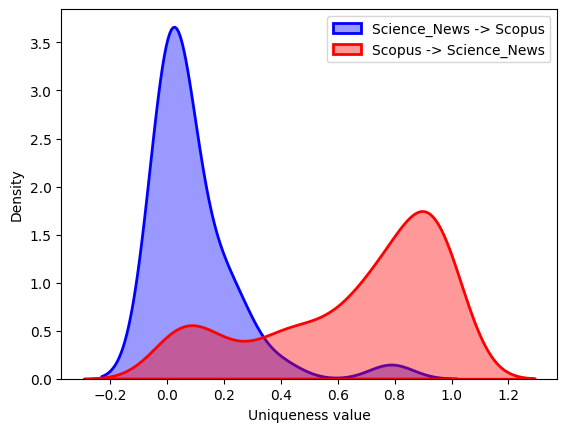

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

model1_to_model2_uniqueness_values = models_metrics.get_topic_uniqueness()['Topic Uniqueness']
full_closeness_topics_model_1 = pd.Series(np.zeros( models_metrics.n_topics_model_1 - len(model1_to_model2_uniqueness_values)))
aggregated_model_1_uniqueness_values = pd.concat([model1_to_model2_uniqueness_values, full_closeness_topics_model_1])

model2_to_model1_uniqueness_values = inverse_models_metrics.get_topic_uniqueness()['Topic Uniqueness']
full_closeness_topics_model_2 = pd.Series(np.zeros( inverse_models_metrics.n_topics_model_1 - len(model2_to_model1_uniqueness_values)))
aggregated_model_2_uniqueness_values = pd.concat([model2_to_model1_uniqueness_values, full_closeness_topics_model_2])

sns.kdeplot(aggregated_model_1_uniqueness_values,
            fill=True,
            alpha=0.4,
            linewidth=2,
            label=f"{models_metrics.model_1_name} -> {models_metrics.model_2_name}",
            color=color_map[models_metrics.model_1_name]
            )
sns.kdeplot(aggregated_model_2_uniqueness_values,
            fill=True,
            alpha=0.4,
            linewidth=2,
            label=f"{inverse_models_metrics.model_1_name} -> {inverse_models_metrics.model_2_name}",
            color=color_map[inverse_models_metrics.model_1_name]
            )

plt.legend()

plt.xlabel("Uniqueness value")
plt.ylabel("Density")


plt.savefig(f'./figures/compare_model_with_BTM_score_figures/{models_metrics.model_1_name}_{models_metrics.model_2_name}_uniqueness_distribution_{models_metrics.percentile_threshold}.png',
            dpi=300,
            bbox_inches="tight")

plt.show()


### Density of topic alignment

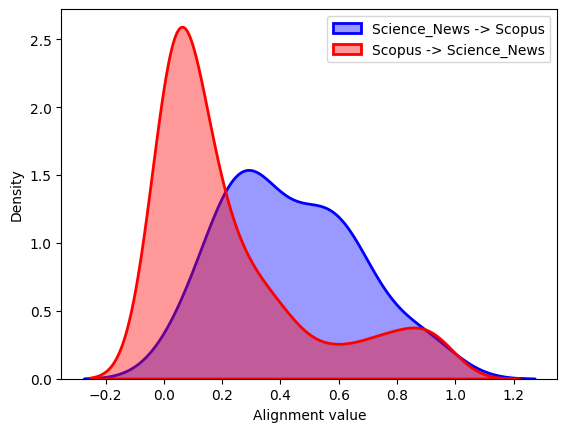

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

model1_to_model2_alignment_values = models_metrics.get_topic_alignment()['Alignment']
full_unique_topics_model_1 = pd.Series(np.zeros( models_metrics.n_topics_model_1 - len(model1_to_model2_alignment_values)))
aggregated_model_1_alignment_values = pd.concat([model1_to_model2_alignment_values, full_unique_topics_model_1])


model2_to_model1_alignment_values = inverse_models_metrics.get_topic_alignment()['Alignment']
full_unique_topics_model_2 = pd.Series(np.zeros( inverse_models_metrics.n_topics_model_1 - len(model2_to_model1_alignment_values)))
aggregated_model_2_alignment_values = pd.concat([model2_to_model1_alignment_values, full_unique_topics_model_2])

sns.kdeplot(aggregated_model_1_alignment_values,
            fill=True,
            alpha=0.4,
            linewidth=2,
            label=f"{models_metrics.model_1_name} -> {models_metrics.model_2_name}",
            color=color_map[models_metrics.model_1_name]
            )
sns.kdeplot(aggregated_model_2_alignment_values,
            fill=True,
            alpha=0.4,
            linewidth=2,
            label=f"{inverse_models_metrics.model_1_name} -> {inverse_models_metrics.model_2_name}",
            color=color_map[inverse_models_metrics.model_1_name]
            )

plt.legend()

plt.xlabel("Alignment value")
plt.ylabel("Density")

plt.savefig(f'./figures/compare_model_with_BTM_score_figures/{models_metrics.model_1_name}_{models_metrics.model_2_name}_alignment_distribution_{models_metrics.percentile_threshold}.png',
            dpi=300,
            bbox_inches="tight")

plt.show()

